# Customer Behaviour Analytics and Product Recommendation System for E-Commerce Using Machine Learning and Data Visualisation

# Data loading and handling missing value

In [ ]:
# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np

# STEP 2: LOAD DATASETS

orders = pd.read_csv(path + "olist_orders_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
category = pd.read_csv(path + "product_category_name_translation.csv")


# STEP 3: QUICK CHECK
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)


In [ ]:
# STEP 4: CHECK MISSING VALUES

print("Missing values in Orders dataset:")
print(orders.isnull().sum())

print("\nMissing values in Customers dataset:")
print(customers.isnull().sum())

print("\nMissing values in Order Items dataset:")
print(order_items.isnull().sum())

print("\nMissing values in Payments dataset:")
print(payments.isnull().sum())

print("\nMissing values in Reviews dataset:")
print(reviews.isnull().sum())

print("\nMissing values in Products dataset:")
print(products.isnull().sum())

Missing values in Orders dataset:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing values in Customers dataset:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing values in Order Items dataset:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing values in Payments dataset:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Missing values in Reviews dataset:
revi

In [ ]:
# CLEAN REVIEWS DATASET

reviews_clean = reviews.copy()

# Fill missing text values
reviews_clean['review_comment_title'] = reviews_clean['review_comment_title'].fillna("No Title")
reviews_clean['review_comment_message'] = reviews_clean['review_comment_message'].fillna("No Comment")

# Check again
print(reviews_clean.isnull().sum())

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


In [ ]:

# CLEAN PRODUCTS DATASET
products_clean = products.copy()

# Fill missing category
products_clean['product_category_name'] = products_clean['product_category_name'].fillna("unknown")

# Fill numeric values with median
numeric_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in numeric_cols:
    products_clean[col] = products_clean[col].fillna(products_clean[col].median())

# Check again
print(products_clean.isnull().sum())

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [ ]:
# CLEAN ORDERS DATASET

orders_clean = orders.copy()

# Convert date columns
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors='coerce')

# Keep missing values
print(orders_clean.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


#Checking duplicate value

In [ ]:
#  CHECK DUPLICATES

datasets = {
    "Orders": orders_clean,
    "Customers": customers,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews_clean,
    "Products": products_clean
}

for name, df in datasets.items():
    print("\n==================")
    print(f"{name} Dataset")
    print("===================")
    print("Duplicate rows:", df.duplicated().sum())


Orders Dataset
Duplicate rows: 0

Customers Dataset
Duplicate rows: 0

Order Items Dataset
Duplicate rows: 0

Payments Dataset
Duplicate rows: 0

Reviews Dataset
Duplicate rows: 0

Products Dataset
Duplicate rows: 0


#Data Merging

In [ ]:
# STEP: DATA MERGING

import pandas as pd
import numpy as np

# 1. Create clean copies first

customers_clean = customers.copy()
order_items_clean = order_items.copy()
payments_clean = payments.copy()

# 2. Standard cleaning for datasets

# Customers
customers_clean = customers_clean.drop_duplicates()
customers_clean['customer_city'] = customers_clean['customer_city'].str.strip().str.lower()
customers_clean['customer_state'] = customers_clean['customer_state'].str.strip().str.upper()

# Order items
order_items_clean = order_items_clean.drop_duplicates()
order_items_clean['shipping_limit_date'] = pd.to_datetime(order_items_clean['shipping_limit_date'], errors='coerce')
order_items_clean['item_total_value'] = order_items_clean['price'] + order_items_clean['freight_value']

# Payments
payments_clean = payments_clean.drop_duplicates()
payments_clean['payment_type'] = payments_clean['payment_type'].str.strip().str.lower()


# 3. Aggregate payments by order_id
#    because one order can have multiple payment rows
payments_agg = payments_clean.groupby('order_id', as_index=False).agg({
    'payment_value': 'sum',
    'payment_installments': 'max'
})

# Most common payment type per order
payment_type_mode = (
    payments_clean.groupby('order_id')['payment_type']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
)

payments_agg = payments_agg.merge(payment_type_mode, on='order_id', how='left')

print("Payments aggregated shape:", payments_agg.shape)
display(payments_agg.head())

# 4. Aggregate reviews by order_id
#    One order should have one review summary
reviews_agg = reviews_clean.groupby('order_id', as_index=False).agg({
    'review_score': 'mean',
    'review_comment_title': 'first',
    'review_comment_message': 'first'
})

print("Reviews aggregated shape:", reviews_agg.shape)
display(reviews_agg.head())

# 5. Merge orders + customers
merged_df = pd.merge(
    orders_clean,
    customers_clean,
    on='customer_id',
    how='left'
)

print("After merging orders + customers:", merged_df.shape)

# 6. Merge order items

merged_df = pd.merge(
    merged_df,
    order_items_clean,
    on='order_id',
    how='left'
)

print("After merging order items:", merged_df.shape)

# 7. Merge products

merged_df = pd.merge(
    merged_df,
    products_clean,
    on='product_id',
    how='left'
)

print("After merging products:", merged_df.shape)


# 8. Merge aggregated payments

merged_df = pd.merge(
    merged_df,
    payments_agg,
    on='order_id',
    how='left'
)

print("After merging payments:", merged_df.shape)

# 9. Merge aggregated reviews

merged_df = pd.merge(
    merged_df,
    reviews_agg,
    on='order_id',
    how='left'
)

print("After merging reviews:", merged_df.shape)

# 10. Final quick check

print("\nFinal merged dataset shape:", merged_df.shape)
print("\nMissing values in merged dataset:")
print(merged_df.isnull().sum().sort_values(ascending=False).head(20))

display(merged_df.head())

Payments aggregated shape: (99440, 4)


,order_id,payment_value,payment_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


Reviews aggregated shape: (98673, 4)


,order_id,review_score,review_comment_title,review_comment_message
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,No Title,"Perfeito, produto entregue antes do combinado."
1,00018f77f2f0320c557190d7a144bdd3,4.0,No Title,No Comment
2,000229ec398224ef6ca0657da4fc703e,5.0,No Title,Chegou antes do prazo previsto e o produto sur...
3,00024acbcdf0a6daa1e931b038114c75,4.0,No Title,No Comment
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,No Title,Gostei pois veio no prazo determinado .


After merging orders + customers: (99441, 12)
After merging order items: (113425, 19)
After merging products: (113425, 27)
After merging payments: (113425, 30)
After merging reviews: (113425, 33)

Final merged dataset shape: (113425, 33)

Missing values in merged dataset:
order_delivered_customer_date    3229
order_delivered_carrier_date     1968
review_comment_title              961
review_score                      961
review_comment_message            961
product_width_cm                  775
product_id                        775
shipping_limit_date               775
price                             775
product_name_lenght               775
product_category_name             775
item_total_value                  775
product_description_lenght        775
freight_value                     775
seller_id                         775
order_item_id                     775
product_length_cm                 775
product_photos_qty                775
product_weight_g                  775
produ

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,500.0,19.0,8.0,13.0,38.71,1.0,voucher,4.0,No Title,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,400.0,19.0,13.0,19.0,141.46,1.0,boleto,4.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,420.0,24.0,19.0,21.0,179.12,3.0,credit_card,5.0,No Title,No Comment
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,450.0,30.0,10.0,20.0,72.20,1.0,credit_card,5.0,No Title,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,250.0,51.0,15.0,15.0,28.62,1.0,credit_card,5.0,No Title,No Comment


In [ ]:
# Save final merged dataset
merged_df.to_csv("/content/final_merged_olist_dataset.csv", index=False)
print("Final merged dataset saved successfully.")

Final merged dataset saved successfully.


#CREATE DASHBOARD DATASET'

In [ ]:
# Create dashboard dataset from merged dataset
dashboard_df = merged_df.copy()

# Check shape
print("Dashboard dataset shape:", dashboard_df.shape)

# Check missing values
print("\nMissing values in dashboard dataset:")
print(dashboard_df.isnull().sum().sort_values(ascending=False).head(20))
# Preview first 5 rows
display(dashboard_df.head())

Dashboard dataset shape: (113425, 33)

Missing values in dashboard dataset:
order_delivered_customer_date    3229
order_delivered_carrier_date     1968
product_name_lenght               775
shipping_limit_date               775
price                             775
product_id                        775
seller_id                         775
order_item_id                     775
freight_value                     775
item_total_value                  775
product_category_name             775
product_photos_qty                775
product_description_lenght        775
order_approved_at                 161
payment_type                        3
payment_installments                3
payment_value                       3
order_id                            0
customer_zip_code_prefix            0
customer_state                      0
dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,500.0,19.0,8.0,13.0,38.71,1.0,voucher,4.0,No Title,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,400.0,19.0,13.0,19.0,141.46,1.0,boleto,4.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,420.0,24.0,19.0,21.0,179.12,3.0,credit_card,5.0,No Title,No Comment
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,450.0,30.0,10.0,20.0,72.20,1.0,credit_card,5.0,No Title,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,250.0,51.0,15.0,15.0,28.62,1.0,credit_card,5.0,No Title,No Comment


Dashboard dataset saved successfully.


In [ ]:
# Handling dashboard dataset for better analysis
dashboard_df['product_category_name'] = dashboard_df['product_category_name'].fillna("unknown")

dashboard_df['payment_type'] = dashboard_df['payment_type'].fillna("unknown")
dashboard_df['payment_value'] = dashboard_df['payment_value'].fillna(0)
# Check missing values
print("\nMissing values in dashboard dataset:")
print(dashboard_df.isnull().sum().sort_values(ascending=False).head(20))


Missing values in dashboard dataset:
order_delivered_customer_date    3229
order_delivered_carrier_date     1968
product_description_lenght        775
shipping_limit_date               775
price                             775
product_id                        775
seller_id                         775
order_item_id                     775
freight_value                     775
item_total_value                  775
product_name_lenght               775
product_photos_qty                775
order_approved_at                 161
payment_installments                3
order_id                            0
customer_unique_id                  0
order_estimated_delivery_date       0
customer_city                       0
customer_zip_code_prefix            0
customer_state                      0
dtype: int64


In [ ]:
# Save dashboard dataset
dashboard_df.to_csv("/content/dashboard_dataset_powerBI.csv", index=False)
print("Dashboard dataset saved successfully.")

Dashboard dataset saved successfully.


#CREATE ML DATASET

In [ ]:

# CREATE ML DATASET

# Create ML dataset from merged dataset
ml_df = merged_df.copy()

# 1. Remove rows without valid transaction info
# These rows do NOT represent real purchases
# and will break clustering/recommendation

ml_df = ml_df.dropna(subset=['product_id', 'seller_id', 'price'])

print("ML dataset shape:", ml_df.shape)


# 2. Verify cleaning worked
print("\nMissing values in key columns:")
print(ml_df[['product_id', 'seller_id', 'price']].isnull().sum())


# 3. Check remaining missing values
print("\nRemaining missing values (top 20):")
print(ml_df.isnull().sum().sort_values(ascending=False).head(20))

# Preview dataset
display(ml_df.head())


# 4. Save dataset
ml_df.to_csv("/content/ml_dataset.csv", index=False)
print("ML dataset saved successfully.")

ML dataset shape: (112650, 33)

Missing values in key columns:
product_id    0
seller_id     0
price         0
dtype: int64

Remaining missing values (top 20):
order_delivered_customer_date    2454
order_delivered_carrier_date     1194
order_approved_at                  15
payment_type                        3
payment_value                       3
payment_installments                3
order_id                            0
order_purchase_timestamp            0
customer_id                         0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
order_status                        0
order_estimated_delivery_date       0
customer_unique_id                  0
price                               0
shipping_limit_date                 0
seller_id                           0
dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,500.0,19.0,8.0,13.0,38.71,1.0,voucher,4.0,No Title,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,400.0,19.0,13.0,19.0,141.46,1.0,boleto,4.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,420.0,24.0,19.0,21.0,179.12,3.0,credit_card,5.0,No Title,No Comment
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,450.0,30.0,10.0,20.0,72.20,1.0,credit_card,5.0,No Title,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,250.0,51.0,15.0,15.0,28.62,1.0,credit_card,5.0,No Title,No Comment


ML dataset saved successfully.


In [ ]:
# FINAL CLEANING FOR ML DATASET
# Create copy for safety
ml_clean_df = ml_df.copy()

# 1. Handle payment-related missing values
# payment_value → fill with median
ml_clean_df['payment_value'] = ml_clean_df['payment_value'].fillna(
    ml_clean_df['payment_value'].median()
)

# payment_installments → fill with 1 (default)
ml_clean_df['payment_installments'] = ml_clean_df['payment_installments'].fillna(1)

# payment_type → fill with 'unknown'
ml_clean_df['payment_type'] = ml_clean_df['payment_type'].fillna("unknown")

# 2. Do NOT remove delivery-related missing
# (as these are real-world values)

# 3. Check final missing values

print("Final missing values in ML dataset:")
print(ml_clean_df.isnull().sum().sort_values(ascending=False).head(15))


# 4. Verify key columns again
print("\nCheck key ML columns:")
print(ml_clean_df[['product_id', 'seller_id', 'price']].isnull().sum())


# 5. Save final ML dataset
ml_clean_df.to_csv("/content/ml_clean_dataset.csv", index=False)
print("\nFinal ML dataset saved successfully.")

Final missing values in ML dataset:
order_delivered_customer_date    2454
order_delivered_carrier_date     1194
order_approved_at                  15
order_id                            0
customer_id                         0
order_purchase_timestamp            0
order_status                        0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
dtype: int64

Check key ML columns:
product_id    0
seller_id     0
price         0
dtype: int64

Final ML dataset saved successfully.


#Customer level dataset for Clustering

In [ ]:
# CREATE CUSTOMER-LEVEL DATASET
# FOR CLUSTERING

# Use the cleaned ML dataset
customer_base = ml_clean_df.copy()

# Make sure date columns are in datetime format
customer_base['order_purchase_timestamp'] = pd.to_datetime(
    customer_base['order_purchase_timestamp'], errors='coerce'
)

customer_base['order_delivered_customer_date'] = pd.to_datetime(
    customer_base['order_delivered_customer_date'], errors='coerce'
)

# Create delivery_days if it does not already exist
if 'delivery_days' not in customer_base.columns:
    customer_base['delivery_days'] = (
        customer_base['order_delivered_customer_date'] -
        customer_base['order_purchase_timestamp']
    ).dt.days

# Create customer-level behavioural dataset
customer_df = customer_base.groupby('customer_unique_id').agg({
    'order_id': 'nunique',                  # number of orders
    'payment_value': 'sum',                 # total spending
    'review_score': 'mean',                 # average satisfaction
    'delivery_days': 'mean',                # average delivery time
    'order_purchase_timestamp': 'max'       # most recent purchase date
}).reset_index()

# Rename columns
customer_df.columns = [
    'customer_unique_id',
    'order_count',
    'total_spending',
    'avg_review_score',
    'avg_delivery_days',
    'last_purchase_date'
]

# Create recency feature
reference_date = customer_base['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

customer_df['recency_days'] = (
    reference_date - customer_df['last_purchase_date']
).dt.days

# Drop helper column
customer_df = customer_df.drop(columns=['last_purchase_date'])

# Final check
print("Customer-level dataset shape:", customer_df.shape)
print("\nMissing values in customer-level dataset:")
print(customer_df.isnull().sum())

display(customer_df.head())

# Save dataset
customer_df.to_csv("/content/customer_level_dataset.csv", index=False)
print("Customer-level dataset saved successfully.")

Customer-level dataset shape: (95420, 6)

Missing values in customer-level dataset:
customer_unique_id       0
order_count              0
total_spending           0
avg_review_score         0
avg_delivery_days     2064
recency_days             0
dtype: int64


,customer_unique_id,order_count,total_spending,avg_review_score,avg_delivery_days,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,5.0,6.0,116
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,4.0,3.0,119
2,0000f46a3911fa3c0805444483337064,1,86.22,3.0,25.0,542
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,4.0,20.0,326
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,5.0,13.0,293


Customer-level dataset saved successfully.


In [ ]:
# FIX MISSING DELIVERY DAYS
customer_df['avg_delivery_days'] = customer_df['avg_delivery_days'].fillna(
    customer_df['avg_delivery_days'].median()
)

print("Missing values after fix:")
print(customer_df.isnull().sum())

Missing values after fix:
customer_unique_id    0
order_count           0
total_spending        0
avg_review_score      0
avg_delivery_days     0
recency_days          0
dtype: int64


#STEP 1: Prepare data for clustering

In [ ]:
# STEP 1: SELECT FEATURES FOR CLUSTERING
from sklearn.preprocessing import StandardScaler

# Select features (DO NOT include ID)
features = customer_df[[
    'order_count',
    'total_spending',
    'avg_review_score',
    'avg_delivery_days',
    'recency_days'
]]

print(features.head())

   order_count  total_spending  avg_review_score  avg_delivery_days  \
0            1          141.90               5.0                6.0   
1            1           27.19               4.0                3.0   
2            1           86.22               3.0               25.0   
3            1           43.62               4.0               20.0   
4            1          196.89               5.0               13.0   

   recency_days  
0           116  
1           119  
2           542  
3           326  
4           293  


#STEP 2: Scale the data

In [ ]:
# STEP 2: SCALE FEATURES

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Scaled data shape:", scaled_features.shape)

Scaled data shape: (95420, 5)


#STEP 3: Elbow Method (find optimal K)

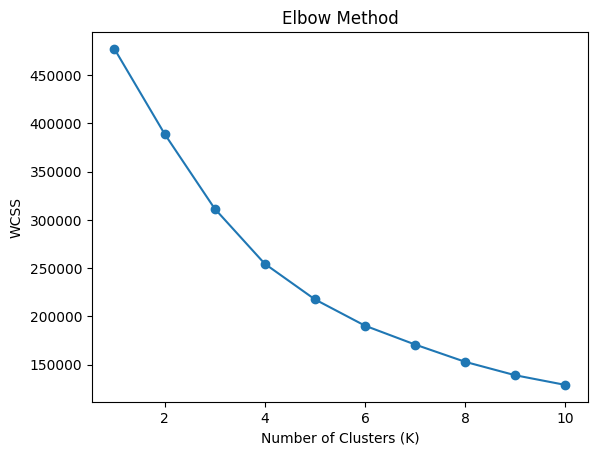

In [ ]:
# STEP 3: ELBOW METHOD
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

#STEP 4: Silhouette Score

In [ ]:
# STEP 4: SILHOUETTE SCORE
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3957
K = 3, Silhouette Score = 0.4247
K = 4, Silhouette Score = 0.3355
K = 5, Silhouette Score = 0.3373
K = 6, Silhouette Score = 0.3518
K = 7, Silhouette Score = 0.3522
K = 8, Silhouette Score = 0.3368
K = 9, Silhouette Score = 0.3407
K = 10, Silhouette Score = 0.2999


# Step 5: K-Means Clustering

In [ ]:
# STEP 5: FINAL K-MEANS CLUSTERING
from sklearn.cluster import KMeans

# Use optimal K
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit model
customer_df['cluster'] = kmeans.fit_predict(scaled_features)

# Check output
print("Cluster assigned successfully\n")
print(customer_df.head())

Cluster assigned successfully

                 customer_unique_id  order_count  total_spending  \
0  0000366f3b9a7992bf8c76cfdf3221e2            1          141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f            1           27.19   
2  0000f46a3911fa3c0805444483337064            1           86.22   
3  0000f6ccb0745a6a4b88665a16c9f078            1           43.62   
4  0004aac84e0df4da2b147fca70cf8255            1          196.89   

   avg_review_score  avg_delivery_days  recency_days  cluster  
0               5.0                6.0           116        0  
1               4.0                3.0           119        0  
2               3.0               25.0           542        2  
3               4.0               20.0           326        0  
4               5.0               13.0           293        0  


#STEP 6: Cluster Analysis

In [ ]:
# STEP 6: CLUSTER SUMMARY

cluster_summary = customer_df.groupby('cluster')[
    [
        'order_count',
        'total_spending',
        'avg_review_score',
        'avg_delivery_days',
        'recency_days'
    ]
].mean().round(2)

print("Cluster Summary:")
display(cluster_summary)

Cluster Summary:


,order_count,total_spending,avg_review_score,avg_delivery_days,recency_days
cluster,,,,,
0,1.00,182.23,4.65,10.12,241.53
1,2.11,559.43,4.13,11.87,226.15
2,1.00,285.31,1.74,20.32,255.29


# Step 7: Cluster Size

In [ ]:
# STEP 7: CLUSTER SIZE
cluster_size = customer_df['cluster'].value_counts().sort_index()

print("Cluster Size:")
print(cluster_size)

Cluster Size:
cluster
0    74861
1     2920
2    17639
Name: count, dtype: int64


In [ ]:
# SAVE CLUSTERED CUSTOMER DATASET
customer_df.to_csv("/content/customer_with_clusters.csv", index=False)
print("Customer clustering dataset saved successfully.")

Customer clustering dataset saved successfully.


#Step 8: Visualizations

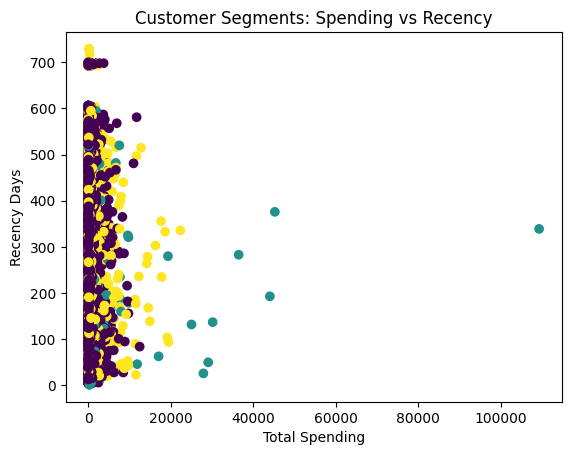

In [ ]:
# VISUALIZATION 1: TOTAL SPENDING vs RECENCY
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    customer_df['total_spending'],
    customer_df['recency_days'],
    c=customer_df['cluster']
)

plt.xlabel("Total Spending")
plt.ylabel("Recency Days")
plt.title("Customer Segments: Spending vs Recency")
plt.show()

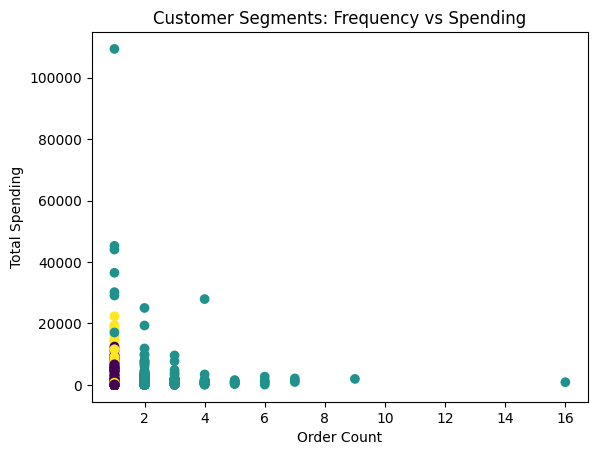

In [ ]:
# VISUALIZATION 2: ORDER COUNT vs SPENDING
plt.figure()
plt.scatter(
    customer_df['order_count'],
    customer_df['total_spending'],
    c=customer_df['cluster']
)

plt.xlabel("Order Count")
plt.ylabel("Total Spending")
plt.title("Customer Segments: Frequency vs Spending")
plt.show()

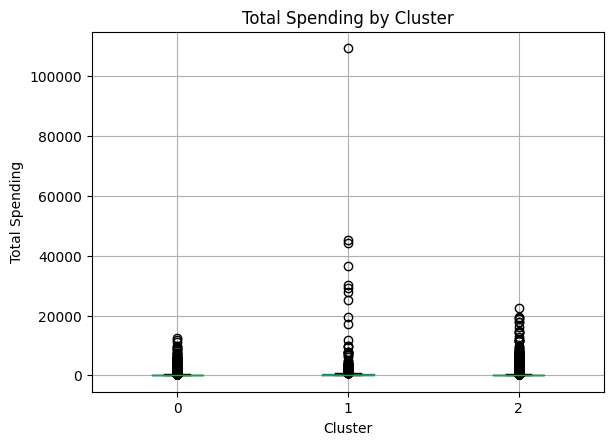

In [ ]:
# VISUALIZATION 3: BOXPLOT OF FEATURES
customer_df.boxplot(column='total_spending', by='cluster')
plt.title("Total Spending by Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Total Spending")
plt.show()

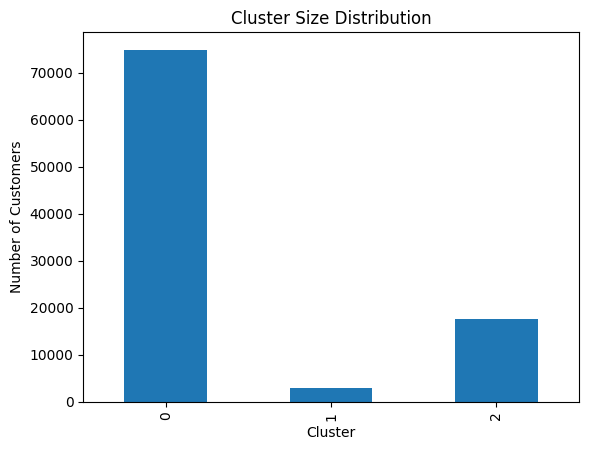

In [ ]:
# VISUALIZATION 4: CLUSTER SIZE
cluster_counts = customer_df['cluster'].value_counts().sort_index()

plt.figure()
cluster_counts.plot(kind='bar')

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Cluster Size Distribution")
plt.show()

#Transaction Dataset for recommendation system

In [ ]:
# Create copy of ML cleaned dataset
rec_df = ml_clean_df.copy()

# Merge translation table
rec_df = rec_df.merge(
    category,
    on='product_category_name',
    how='left'
)
# Check missing values
print(rec_df['product_category_name_english'].isnull().sum())

# Check result
print(rec_df[['product_category_name', 'product_category_name_english']].head())

1627
   product_category_name product_category_name_english
0  utilidades_domesticas                    housewares
1             perfumaria                     perfumery
2             automotivo                          auto
3               pet_shop                      pet_shop
4              papelaria                    stationery


In [ ]:
# Fill missing English category names
rec_df['product_category_name_english'] = rec_df['product_category_name_english'].fillna('unknown')

# Check missing values
print(rec_df['product_category_name_english'].isnull().sum())

0


#Create category-based transaction dataset

In [ ]:
#Step 1: Product-level transaction data
transaction_df = ml_clean_df[['order_id', 'product_id', 'product_category_name']].dropna()

# Remove duplicates
transaction_df = transaction_df.drop_duplicates()

print("Transaction dataset shape:", transaction_df.shape)
display(transaction_df.head())

Transaction dataset shape: (102425, 3)


,order_id,product_id,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,papelaria


In [ ]:
#Step 2: Count products per order
order_product_count = transaction_df.groupby('order_id')['product_id'].nunique()

# Keep only orders with at least 2 products
multi_product_orders = order_product_count[order_product_count >= 2].index

transaction_multi = transaction_df[transaction_df['order_id'].isin(multi_product_orders)]

print("Orders with 2+ products:", transaction_multi['order_id'].nunique())
print("Rows after filtering:", transaction_multi.shape)

Orders with 2+ products: 3236
Rows after filtering: (6995, 3)


In [ ]:
# STEP 3: KEEP ONLY FREQUENTLY PURCHASED PRODUCTS

# Count how many times each product appears
product_counts = transaction_multi['product_id'].value_counts()

# Keep products purchased at least 5 times
# Start with 5 because only 3,236 orders have multiple products
frequent_products = product_counts[product_counts >= 5].index

transaction_filtered = transaction_multi[
    transaction_multi['product_id'].isin(frequent_products)
].copy()

print("Filtered transaction shape:", transaction_filtered.shape)
print("Number of products kept:", transaction_filtered['product_id'].nunique())
print("Number of orders kept:", transaction_filtered['order_id'].nunique())

display(transaction_filtered.head())

Filtered transaction shape: (1163, 3)
Number of products kept: 131
Number of orders kept: 807


,order_id,product_id,product_category_name
68,688052146432ef8253587b930b01a06d,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios
336,c26b94aa87e95d1c1eb1b592f43eb223,99a4788cb24856965c36a24e339b6058,cama_mesa_banho
337,c26b94aa87e95d1c1eb1b592f43eb223,35afc973633aaeb6b877ff57b2793310,casa_conforto
400,b52d29abb97a3978df1d8922bfe36fbe,5f42d57952b7815098979a5c4fa6f82a,beleza_saude
582,65d7e9625cc211f641191203e231ac24,99a4788cb24856965c36a24e339b6058,cama_mesa_banho


In [ ]:
# STEP 4: CREATE BASKET MATRIX
# Create basket matrix:
# Rows = orders
# Columns = products
# Values = True/False whether product exists in order

basket = pd.crosstab(
    transaction_filtered['order_id'],
    transaction_filtered['product_id']
)

# Convert values to Boolean format for Apriori
basket = basket.astype(bool)

print("Basket matrix shape:", basket.shape)

# Preview basket matrix
display(basket.head())

Basket matrix shape: (807, 131)


product_id,014a8a503291921f7b004a5215bb3c36,0152f69b6cf919bcdaf117aa8c43e5a2,017692475c1c954ff597feda05131d73,056d012d264624accb7f73d31caee034,060cb19345d90064d1015407193c233d,060f0122cdc8f25db4a0d7359fdae7b0,06edb72f1e0c64b14c5b79353f7abea3,07c055536ebf10dfbb6c6db6dbfc36e5,07ffc018eaf23e086370dea42c74077b,0a4093a4af429dc0a9334300e5c13ae5,...,ee57070aa3b24a06fdd0e02efd2d757d,f2e53dd1670f3c376518263b3f71424d,f2ecbb02b6da187a9f14b8ac5781faec,f4d705aa95ccca448e5b0deb6e5290ba,f4f67ccaece962d013a4e1d7dc3a61f7,fb55982be901439613a95940feefd9ee,fbc1488c1a1e72ba175f53ab29a248e8,fbce4c4cb307679d89a3bf3d3bb353b9,fc5dd987f12a7b823a76a44aa1ba88f6,ff2c1ec09b1bb340e84f0d6b21cc7dbb
order_id,,,,,,,,,,,,,,,,,,,,,
002f98c0f7efd42638ed6100ca699b42,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
00bcee890eba57a9767c7b5ca12d3a1b,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
01144cadcf64b6427f0a6580a3033220,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
012a238ab54294a3b365812ccc82b135,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
0132451f29a10b66a5cf1bacc85f9afe,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# STEP 5: APPLY APRIORI (FREQUENT ITEMSETS)
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.02,   # as per dataset size
    use_colnames=True
)

print("Number of frequent itemsets:", len(frequent_itemsets))

# Sort by most frequent
frequent_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

display(frequent_itemsets.head(10))

Number of frequent itemsets: 15


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
9,0.064436,(99a4788cb24856965c36a24e339b6058)
4,0.059480,(36f60d45225e60c7da4558b070ce4b60)
10,0.047088,(e53e557d5a159f5aa2c5e995dfdf244b)
2,0.044610,(35afc973633aaeb6b877ff57b2793310)
13,0.042131,"(36f60d45225e60c7da4558b070ce4b60, e53e557d5a1..."
6,0.039653,(422879e10f46682990de24d770e7f83d)
8,0.035936,(53759a2ecddad2bb87a079a1f1519f73)
12,0.035936,"(35afc973633aaeb6b877ff57b2793310, 99a4788cb24..."
5,0.034696,(389d119b48cf3043d311335e499d9c6b)
3,0.033457,(368c6c730842d78016ad823897a372db)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# STEP 5.1: CATEGORY-LEVEL TRANSACTION DATA
# Using filtered multi-product dataset
transaction_cat = transaction_filtered[['order_id', 'product_category_name']].dropna()

# Remove duplicates (same category in same order)
transaction_cat = transaction_cat.drop_duplicates()

print("Transaction category shape:", transaction_cat.shape)
display(transaction_cat.head())

Transaction category shape: (853, 2)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,order_id,product_category_name
68,688052146432ef8253587b930b01a06d,informatica_acessorios
336,c26b94aa87e95d1c1eb1b592f43eb223,cama_mesa_banho
337,c26b94aa87e95d1c1eb1b592f43eb223,casa_conforto
400,b52d29abb97a3978df1d8922bfe36fbe,beleza_saude
582,65d7e9625cc211f641191203e231ac24,cama_mesa_banho


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
transaction_cat.groupby('order_id').size().value_counts().head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,count
1,761
2,46


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# STEP 5.2: BASKET MATRIX (CATEGORY)
basket_cat = pd.crosstab(
    transaction_cat['order_id'],
    transaction_cat['product_category_name']
)

# Convert to True/False
basket_cat = basket_cat.astype(bool)

print("Basket category shape:", basket_cat.shape)
display(basket_cat.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Basket category shape: (807, 18)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


product_category_name,automotivo,bebes,beleza_saude,brinquedos,cama_mesa_banho,casa_conforto,consoles_games,construcao_ferramentas_jardim,fashion_bolsas_e_acessorios,ferramentas_jardim,informatica_acessorios,market_place,moveis_decoracao,papelaria,perfumaria,relogios_presentes,telefonia,unknown
order_id,,,,,,,,,,,,,,,,,,
002f98c0f7efd42638ed6100ca699b42,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
00bcee890eba57a9767c7b5ca12d3a1b,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
01144cadcf64b6427f0a6580a3033220,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
012a238ab54294a3b365812ccc82b135,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
0132451f29a10b66a5cf1bacc85f9afe,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# STEP 5.3: FREQUENT ITEMSETS (CATEGORY)

from mlxtend.frequent_patterns import apriori

frequent_itemsets_cat = apriori(
    basket_cat,
    min_support=0.02,   # same logic as before
    use_colnames=True
)

print("Number of frequent itemsets:", len(frequent_itemsets_cat))

frequent_itemsets_cat = frequent_itemsets_cat.sort_values(
    by='support',
    ascending=False
)

display(frequent_itemsets_cat.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Number of frequent itemsets: 10


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
3,0.319703,(cama_mesa_banho)
6,0.159851,(informatica_acessorios)
8,0.111524,(relogios_presentes)
5,0.110285,(ferramentas_jardim)
2,0.076828,(beleza_saude)
7,0.058240,(moveis_decoracao)
0,0.048327,(automotivo)
4,0.044610,(casa_conforto)
9,0.039653,"(cama_mesa_banho, casa_conforto)"
1,0.030979,(bebes)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# TRANSLATE FREQUENT ITEMSETS AFTER APRIORI
# Create dictionary: Portuguese category -> English category
category_dict = dict(
    zip(category['product_category_name'], category['product_category_name_english'])
)

# Function to translate itemsets
def translate_itemset(itemset):
    return tuple(category_dict.get(item, item) for item in itemset)

# Apply translation
frequent_itemsets_cat['itemsets_english'] = frequent_itemsets_cat['itemsets'].apply(translate_itemset)

# Display translated result
display(frequent_itemsets_cat[['support', 'itemsets_english']].head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets_english
3,0.319703,"(bed_bath_table,)"
6,0.159851,"(computers_accessories,)"
8,0.111524,"(watches_gifts,)"
5,0.110285,"(garden_tools,)"
2,0.076828,"(health_beauty,)"
7,0.058240,"(furniture_decor,)"
0,0.048327,"(auto,)"
4,0.044610,"(home_confort,)"
9,0.039653,"(bed_bath_table, home_confort)"
1,0.030979,"(baby,)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from mlxtend.frequent_patterns import association_rules

rules_cat = association_rules(
    frequent_itemsets_cat,
    metric="lift",
    min_threshold=1
)

rules_cat = rules_cat.sort_values(
    by=['lift', 'confidence'],
    ascending=False
)

# Translate rules
def translate_rule_items(itemset):
    return ', '.join(category_dict.get(item, item) for item in itemset)

rules_cat['antecedents_english'] = rules_cat['antecedents'].apply(translate_rule_items)
rules_cat['consequents_english'] = rules_cat['consequents'].apply(translate_rule_items)

rules_cat_clean = rules_cat[[
    'antecedents_english',
    'consequents_english',
    'support',
    'confidence',
    'lift'
]]

display(rules_cat_clean.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents_english,consequents_english,support,confidence,lift
1,home_confort,bed_bath_table,0.039653,0.888889,2.780362
0,bed_bath_table,home_confort,0.039653,0.124031,2.780362


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# FILTER STRONG RULES

strong_rules = rules_cat_clean[
    (rules_cat_clean['confidence'] >= 0.5) &
    (rules_cat_clean['lift'] > 1.5)
]

print("Strong rules:")
display(strong_rules)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Strong rules:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents_english,consequents_english,support,confidence,lift
1,home_confort,bed_bath_table,0.039653,0.888889,2.780362


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

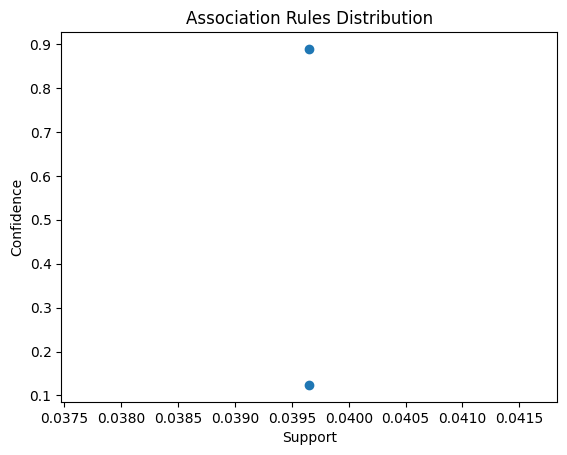

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(rules_cat['support'], rules_cat['confidence'])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules Distribution")
plt.show()